In [1]:
import os 
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path) 

In [2]:
model_train_outputs_path = repo_path + "/results/poisson_setup1/model_train_outputs/rbno_physics_loss/test"
model_test_outputs_path = repo_path + "/results/poisson_setup1/model_test_outputs/rbno_physics_loss/test"

In [3]:
num_train_list = [16, 64, 256, 1024, 4096]

In [4]:
sigma_u_error_dict_list = []
for num_train in num_train_list:
    sigma_u_error_dict = np.load(os.path.join(model_test_outputs_path, f'sigma_u_error_dict_{num_train}.npy'), allow_pickle=True).item()
    sigma_u_error_dict_list.append(sigma_u_error_dict)

In [5]:
relative_bochner_L2_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    relative_bochner_L2_error = sigma_u_error_dict['relative_bochner_L2']
    relative_bochner_L2_error_list.append(relative_bochner_L2_error)

In [6]:
relative_bochner_hdiv_h1_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    relative_bochner_hdiv_h1 = sigma_u_error_dict['relative_bochner_hdiv_h1']
    relative_bochner_hdiv_h1_error_list.append(relative_bochner_hdiv_h1)

In [7]:
bochner_L2_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    bochner_L2_error = sigma_u_error_dict['bochner_L2']
    bochner_L2_error_list.append(bochner_L2_error)

In [8]:
bochner_hdiv_h1_error_list = []
for sigma_u_error_dict in sigma_u_error_dict_list:
    bochner_hdiv_h1_error = sigma_u_error_dict['bochner_hdiv_h1']
    bochner_hdiv_h1_error_list.append(bochner_hdiv_h1_error)

In [9]:
physics_loss_list = []
for num_train in num_train_list:
    physics_loss = np.load(os.path.join(model_test_outputs_path, f'residual_loss_dict_{num_train}.npy'), allow_pickle=True).item()
    physics_loss_list.append(physics_loss)

In [10]:
mean_residual_loss_list = []
for physics_loss in physics_loss_list:
    mean_residual_loss = physics_loss['mean_total_residual_loss']
    mean_residual_loss_list.append(mean_residual_loss)

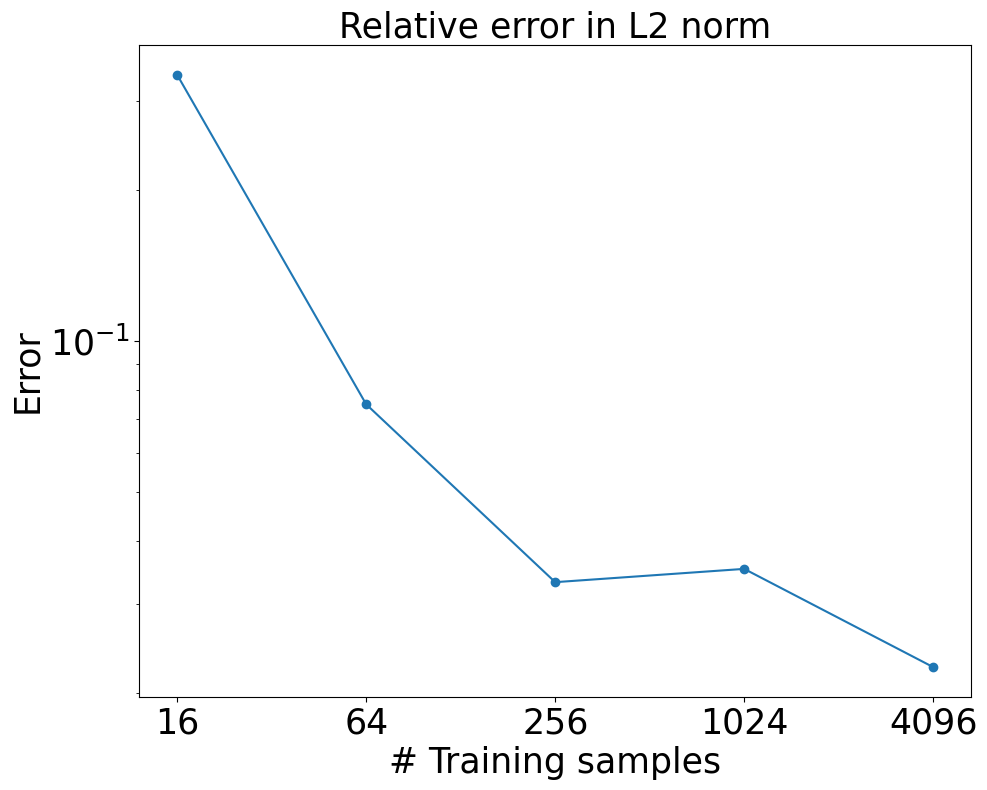

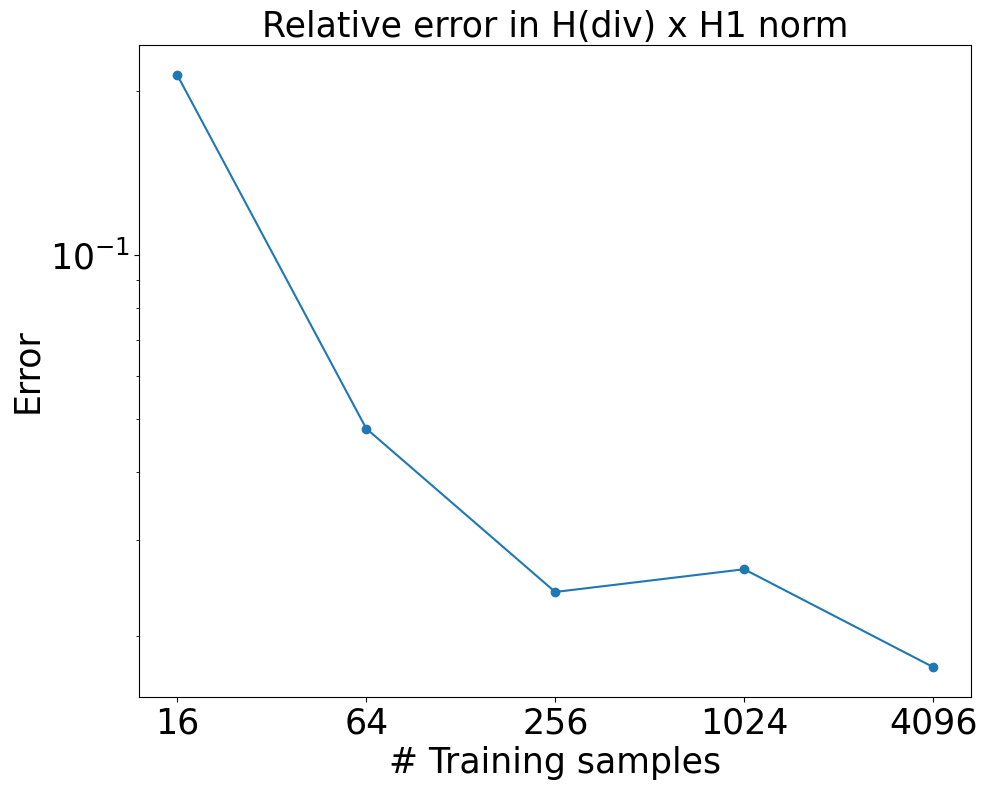

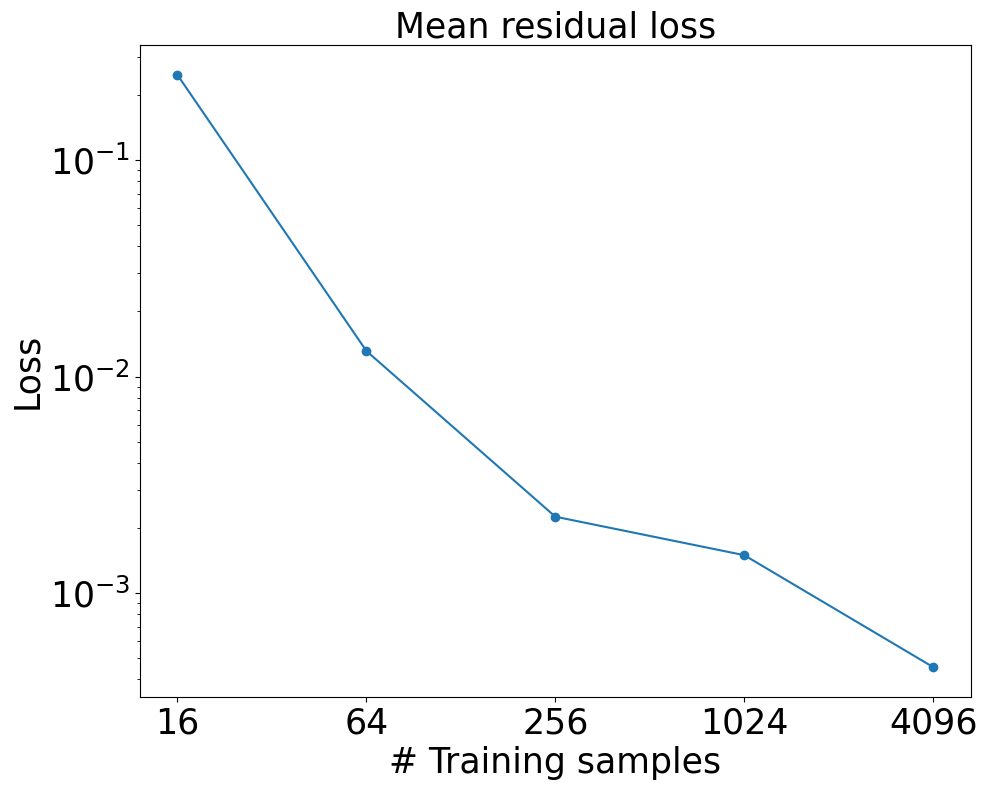

In [16]:
# --- L2 error as percentage ---
plt.figure(figsize=(10,8))
plt.plot(num_train_list, np.array(relative_bochner_L2_error_list), marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_train_list, labels=num_train_list, fontsize=25)
plt.xlabel('# Training samples', fontsize=25)
plt.ylabel('Error', fontsize=25)
plt.yticks(fontsize=25)
plt.title('Relative error in L2 norm', fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(model_test_outputs_path, 'relative_bochner_L2_error_vs_num_train.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- H(div) x H1 error as percentage ---
plt.figure(figsize=(10,8))
plt.plot(num_train_list, np.array(relative_bochner_hdiv_h1_error_list), marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_train_list, labels=num_train_list, fontsize=25)
plt.xlabel('# Training samples', fontsize=25)
plt.ylabel('Error', fontsize=25)
plt.yticks(fontsize=25)
plt.title('Relative error in H(div) x H1 norm', fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(model_test_outputs_path, 'relative_bochner_hdiv_h1_error_vs_num_train.png'), dpi=300, bbox_inches='tight')
plt.show()


# --- Physics loss vs num_train ---
plt.figure(figsize=(10,8))
plt.plot(num_train_list, np.array(mean_residual_loss_list), marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_train_list, labels=num_train_list, fontsize=25)
plt.xlabel('# Training samples', fontsize=25)
plt.ylabel('Loss', fontsize=25)
plt.yticks(fontsize=25)
plt.title('Mean residual loss', fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(model_test_outputs_path, 'mean_residual_loss_vs_num_train.png'), dpi=300, bbox_inches='tight')
plt.show()

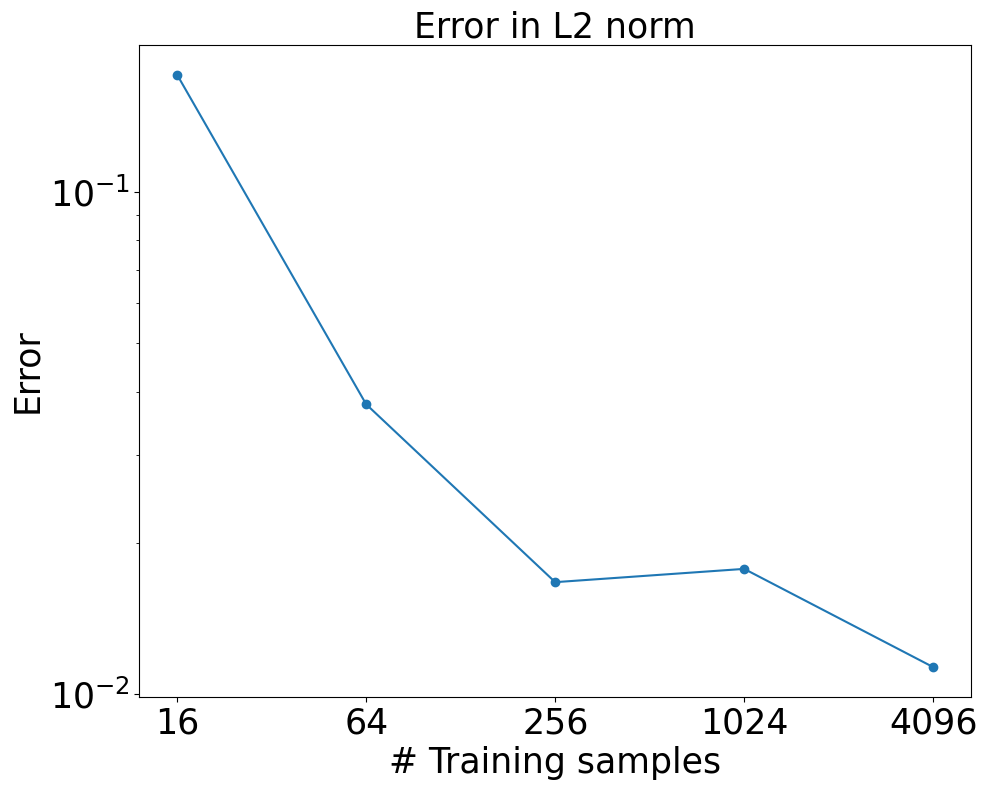

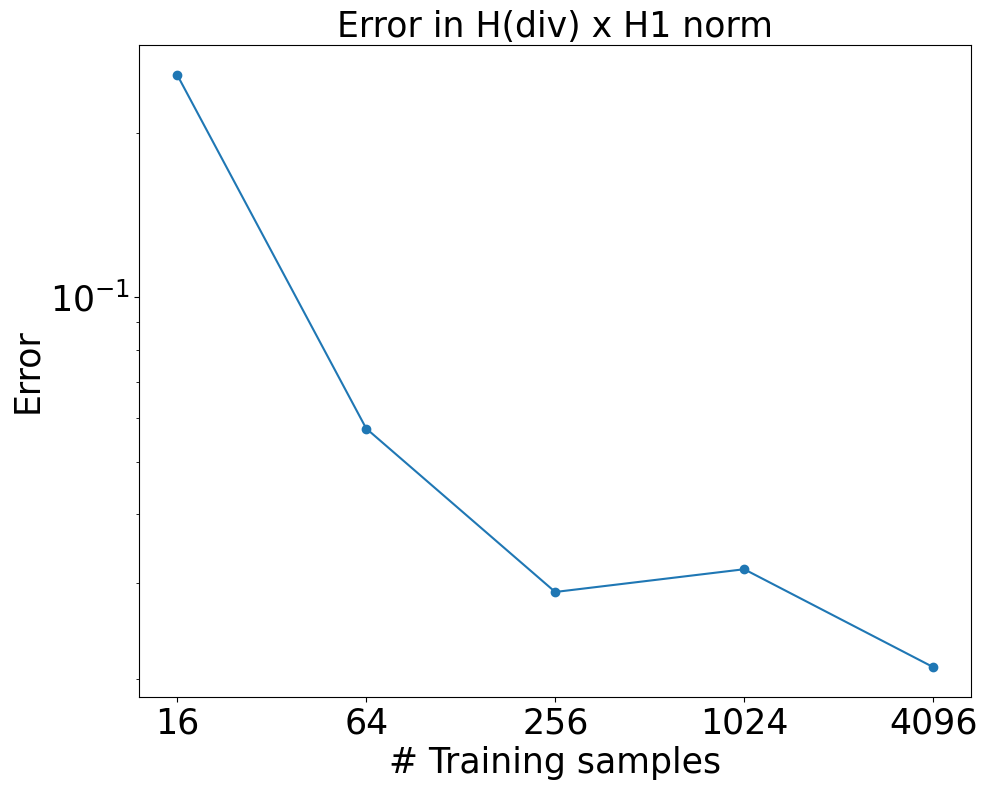

In [17]:
# --- L2 error as percentage ---
plt.figure(figsize=(10,8))
plt.plot(num_train_list, np.array(bochner_L2_error_list), marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_train_list, labels=num_train_list, fontsize=25)
plt.xlabel('# Training samples', fontsize=25)
plt.ylabel('Error', fontsize=25)
plt.yticks(fontsize=25)
plt.title('Error in L2 norm', fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(model_test_outputs_path, 'bochner_L2_error_vs_num_train.png'),dpi=300, bbox_inches='tight')
plt.show()

# --- H(div) x H1 error as percentage ---
plt.figure(figsize=(10,8))
plt.plot(num_train_list, np.array(bochner_hdiv_h1_error_list), marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_train_list, labels=num_train_list, fontsize=25)
plt.xlabel('# Training samples', fontsize=25)
plt.ylabel('Error', fontsize=25)
plt.yticks(fontsize=25)
plt.title('Error in H(div) x H1 norm', fontsize=25)
plt.tight_layout()
plt.savefig(os.path.join(model_test_outputs_path, 'bochner_hdiv_h1_error_vs_num_train.png'),dpi=300, bbox_inches='tight')
plt.show()